/tmp/ipykernel_299/3046389819.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01")['Close'].dropna()
[*********************100%***********************]  2 of 2 completed


MÉTRICAS DE GESTIÓN ACTIVA
Alpha anualizado: 6.44%
Beta: 1.1845
Information ratio: 0.3253

 OPTIMIZACIÓN TREYNOR-BLACK
Asignación óptima en estrategia activa: 83.24%
Asignación en estrategia pasiva (Benchmark): 16.76%

 ANÁLISIS DE ESTRUCTURA DE CAPITAL
Beta de equity (Observado): 1.1845
Beta de activo (Riesgo de negocio): 0.8774
Beta proyectado (Nueva D/E 1.2): 1.6144


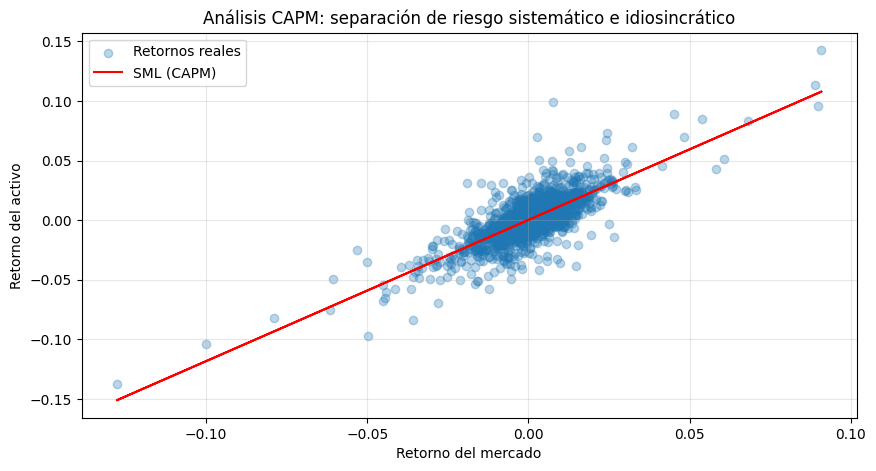

In [1]:
#PROYECTO: Asset_Pricing_and_Factors
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Medición de alpha, optimización Treynor-Black y apalancamiento de Beta

!pip install -q numpy pandas yfinance statsmodels matplotlib

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

#1. ESTIMACIÓN DE CAPM Y MÉTRICAS DE SKILL (Alpha & IR)

#El objetivo es medir si el gestor genera retornos por encima del mercado
tickers = ["AAPL", "^GSPC"]
data = yf.download(tickers, start="2020-01-01")['Close'].dropna()
ret = np.log(data / data.shift(1)).dropna()
ret.columns = ["Stock", "Market"]

Y = ret["Stock"]
X = sm.add_constant(ret["Market"])
model = sm.OLS(Y, X).fit()

alpha = model.params["const"] * 252  #Alpha anualizado (Skill)
beta = model.params["Market"]        #Riesgo sistemático
residual_std = model.resid.std() * np.sqrt(252) #tracking error (riesgo idiosincrático)

#Information Ratio: Calidad del Alpha por unidad de riesgo activo
info_ratio = alpha / residual_std

print(f"MÉTRICAS DE GESTIÓN ACTIVA")
print(f"Alpha anualizado: {alpha:.2%}")
print(f"Beta: {beta:.4f}")
print(f"Information ratio: {info_ratio:.4f}")

#2. OPTIMIZACIÓN TREYNOR-BLACK (active vs passive)
#Determinamos cuánto invertir en el portafolio activo vs el mercado
rf = 0.03 #tasa libre de riesgo
erp = (ret["Market"].mean() * 252) - rf #equity risk premium
mkt_var = (ret["Market"].std() * np.sqrt(252))**2

#Peso óptimo en el portafolio activo (w_A)
w_active = (alpha / residual_std**2) / (erp / mkt_var)

print(f"\n OPTIMIZACIÓN TREYNOR-BLACK")
print(f"Asignación óptima en estrategia activa: {w_active:.2%}")
print(f"Asignación en estrategia pasiva (Benchmark): {1 - w_active:.2%}")

#3. ANÁLISIS DE BETA APALANCADO Y DESAPALANCADO
#Descomponemos el riesgo en operacional y financiero (M&A Application)
tax_rate = 0.30
debt_equity_ratio = 0.50 #Estructura de capital actual

#Beta desapalancado (asset beta): Riesgo puro del negocio
#Formula: Bu = Bl / (1 + (1-T)*(D/E))
beta_unlevered = beta / (1 + (1 - tax_rate) * debt_equity_ratio)

#Re-apalancamiento: ¿Qué pasa si cambiamos la estructura de capital?
new_de_ratio = 1.20 #aumento de deuda
beta_levered_new = beta_unlevered * (1 + (1 - tax_rate) * new_de_ratio)

print(f"\n ANÁLISIS DE ESTRUCTURA DE CAPITAL")
print(f"Beta de equity (Observado): {beta:.4f}")
print(f"Beta de activo (Riesgo de negocio): {beta_unlevered:.4f}")
print(f"Beta proyectado (Nueva D/E {new_de_ratio}): {beta_levered_new:.4f}")

#4. VISUALIZACIÓN DE RESIDUOS (riesgo activo)
plt.figure(figsize=(10, 5))
plt.scatter(ret["Market"], ret["Stock"], alpha=0.3, label="Retornos reales")
plt.plot(ret["Market"], model.predict(X), color='red', label="SML (CAPM)")
plt.title("Análisis CAPM: separación de riesgo sistemático e idiosincrático")
plt.xlabel("Retorno del mercado")
plt.ylabel("Retorno del activo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()